# Live first-down probability

**Question:** at any moment during a pass play, how likely is it that the play ends with a first down (or touchdown)?

* **Pre-snap model:** uses the situation only (down, distance, field position, clock, score, formation, personnel).
* **Live model:** updates every tracking frame (10 per second) from the snap until the pocket phase ends (pass thrown, sack, or QB takes off running), using where everyone is and how they're moving.
* **New stat, ΔP:** live probability at the end of the pocket phase minus at the snap. That's how much the play *after the snap* (protection, pass rush, receivers getting open, QB) moved the odds, before the ball's fate is known.

Everything uses only this project's `data/` folder. Feature code lives in `features.py`, models in `model.py`.
Delete `cache/` if you change `features.py`, so features get rebuilt.

In [1]:
import sys, time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd()))
import features as F
import model as M

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
OUT, CACHE = Path("outputs"), Path("cache")
OUT.mkdir(exist_ok=True); CACHE.mkdir(exist_ok=True)

## 1. Labels

`converted = 1` when the offense completes a pass or scrambles **and** gains at least `yardsToGo` (before penalties) or scores.

Removed: plays wiped out by a penalty ("No Play") and two-point tries (`down == 0`). Interceptions or fumbles returned for a *defensive* touchdown count as 0.

In [2]:
plays = F.load_plays()
print(f"{len(plays):,} plays kept · conversion rate {plays.converted.mean():.1%}")
display(plays.groupby("down").converted.agg(rate="mean", plays="size").round(3))
display(plays.groupby("passResult").converted.agg(rate="mean", plays="size").round(3))

8,034 plays kept · conversion rate 34.8%


,rate,plays
down,,
1,0.300,2901
2,0.360,2681
3,0.389,2234
4,0.431,218


,rate,plays
passResult,,
C,0.586,4469
I,0.000,2451
IN,0.000,176
R,0.427,419
S,0.000,519


## 2. Frame features

Tracking is flipped so the offense always moves right. Roles (rusher, blocker, receiver, coverage, QB) come from `pffScoutingData.csv`. They're assigned per play by PFF, which also matches how the defense lines up at the snap.

| Group | Features |
|---|---|
| Time | seconds since snap, play-action shown yet, end-of-pocket flags (thrown / sacked / scrambling) |
| QB | depth behind the line, sideways drift, speed |
| Pass rush | # rushers, nearest rusher distance & closing speed, rushers within 2 / 3.5 yd, rushers with no blocker within 1.5 yd ("free"), est. time for nearest rusher to reach the QB |
| Pocket | area of the blockers + QB convex hull, how far blockers have been pushed back |
| Receivers | best separation from nearest defender, # open (≥ 3 yd), # past the first-down line, best separation among receivers near/past the line, depth of the most open receiver vs the line |

In [3]:
t0 = time.time()
frames = F.build_frame_features(plays, cache=CACHE / "frame_features.pkl")
df = M.build_frame_table(plays, frames)
print(f"{len(df):,} frames from {df[M.PLAY_KEY].drop_duplicates().shape[0]:,} plays ({time.time() - t0:.0f}s)")
df[F.FRAME_FEATURES].describe().T[["mean", "min", "50%", "max"]].round(2)

255,007 frames from 8,011 plays (0s)


,mean,min,50%,max
t,1.74,0.00,1.50,9.80
play_action_shown,0.17,0.00,0.00,1.00
is_end_frame,0.03,0.00,0.00,1.00
ended_pass,0.03,0.00,0.00,1.00
ended_sack,0.00,0.00,0.00,1.00
ended_scramble,0.00,0.00,0.00,1.00
qb_depth,6.68,-0.44,6.55,22.86
qb_lateral,1.06,0.00,0.28,30.21
qb_s,2.06,0.00,1.71,9.78
n_rushers,4.22,0.00,4.00,8.00


## 3. Grouped cross-validation

5 folds split **by game**: frames from one play are nearly identical, so a random split would leak. Every play gets an out-of-fold prediction.

The live model gets the pre-snap model's prediction as a feature. In training, that feature comes from an inner cross-validation, so the live model never sees a pre-snap prediction for a play the pre-snap model was trained on.

In [4]:
t0 = time.time()
plays_oof, oof = M.cross_validate(plays, df)
print(f"done in {time.time() - t0:.0f}s")
M.evaluation_table(plays_oof, oof).round(4)

done in 27s


,log_loss,brier,auc,n
Base rate (constant),0.6466,0.2271,0.5000,8011.0
Pre-snap model,0.6183,0.2143,0.6406,8011.0
Live model @ snap,0.6180,0.2144,0.6431,8011.0
Live model @ end of pocket,0.5759,0.1982,0.7143,8011.0
"Live model, all frames (play-weighted)",0.6054,0.2094,0.6659,255007.0


Lower log loss and Brier are better; AUC is how well the model ranks converting plays above non-converting ones (0.5 = coin flip).

**How the live model's accuracy changes as the play goes on** (frames binned by seconds after the snap):

,seconds_after_snap,frames,plays,presnap_log_loss,live_log_loss,presnap_auc,live_auc
0,"[0.0, 0.5)",40055,8011,0.6183,0.6175,0.6406,0.6445
1,"[0.5, 1.0)",40052,8011,0.6183,0.6168,0.6407,0.6459
2,"[1.0, 1.5)",40003,8008,0.6183,0.6167,0.6404,0.6467
3,"[1.5, 2.0)",38949,7977,0.6202,0.6143,0.6358,0.6503
4,"[2.0, 2.5)",32769,7202,0.6284,0.6155,0.6175,0.6463
5,"[2.5, 3.0)",23416,5477,0.6278,0.6019,0.6014,0.6555
6,"[3.0, 4.0)",24011,3553,0.6087,0.5534,0.5920,0.6935
7,"[4.0, 10.0)",15752,1394,0.5509,0.4707,0.5957,0.6921


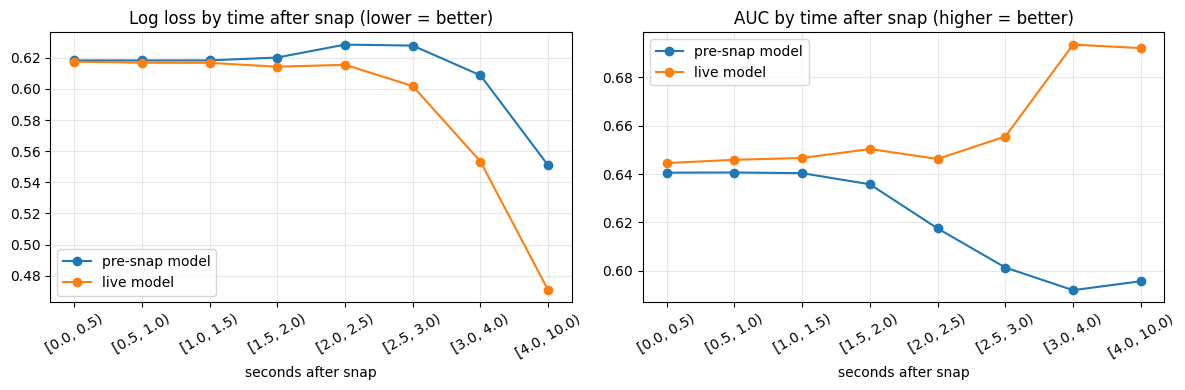

In [5]:
bt = M.by_time_table(oof)
display(bt.round(4))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
x = range(len(bt))
ax[0].plot(x, bt.presnap_log_loss, "o-", label="pre-snap model")
ax[0].plot(x, bt.live_log_loss, "o-", label="live model")
ax[0].set(title="Log loss by time after snap (lower = better)", xticks=list(x), xlabel="seconds after snap")
ax[0].set_xticklabels(bt.seconds_after_snap, rotation=30)
ax[1].plot(x, bt.presnap_auc, "o-", label="pre-snap model")
ax[1].plot(x, bt.live_auc, "o-", label="live model")
ax[1].set(title="AUC by time after snap (higher = better)", xticks=list(x), xlabel="seconds after snap")
ax[1].set_xticklabels(bt.seconds_after_snap, rotation=30)
for a in ax: a.legend(); a.grid(alpha=.3)
plt.tight_layout(); plt.show()

**Calibration:** when the model says 30%, about 30% of those plays should convert.

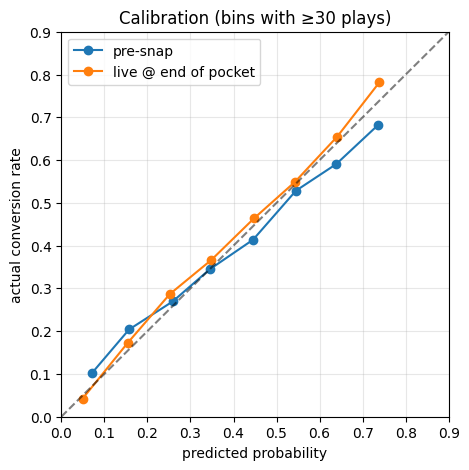

In [6]:
summ = M.summarize_plays(oof)
fig, ax = plt.subplots(figsize=(5, 5))
for col, label in [("p_presnap", "pre-snap"), ("p_end", "live @ end of pocket")]:
    c = M.calibration_table(summ.converted, summ[col])
    c = c[c.n >= 30]
    ax.plot(c.predicted, c.actual, "o-", label=label)
ax.plot([0, 1], [0, 1], "k--", alpha=.5)
ax.set(xlabel="predicted probability", ylabel="actual conversion rate", title="Calibration (bins with ≥30 plays)",
       xlim=(0, .9), ylim=(0, .9))
ax.legend(); ax.grid(alpha=.3); plt.show()

### Is the gain just "sacks are obviously failures"?

A sack is visible in the tracking, so the live model gets those right at the end of the play. Below, only plays where the ball was actually **thrown**. Any gain here comes from reading the pocket and the receivers.

In [7]:
thrown = summ[summ.end_event.isin(["pass_forward", "autoevent_passforward"])]
pd.DataFrame({
    "Pre-snap model": M.scores(thrown.converted, thrown.p_presnap),
    "Live model @ throw": M.scores(thrown.converted, thrown.p_end),
}).T.round(4)

,log_loss,brier,auc,n
Pre-snap model,0.6303,0.2197,0.6408,7091.0
Live model @ throw,0.6082,0.2103,0.6854,7091.0


## 4. What the model looks at

Permutation importance on held-out games (fold 1): how much log loss gets worse when a feature's values are shuffled.

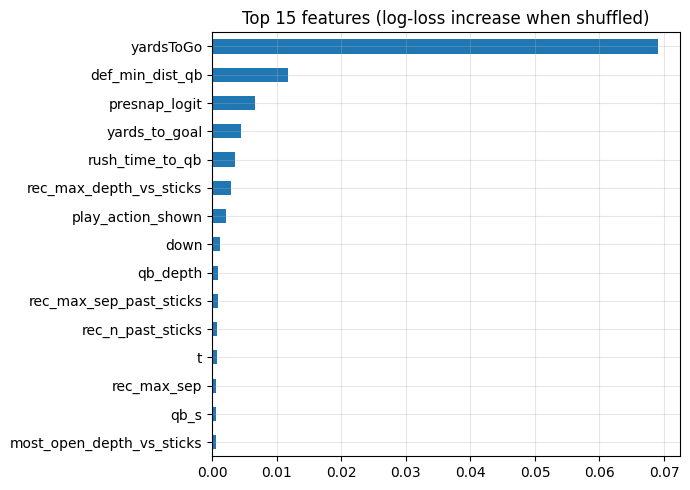

In [8]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import GroupKFold

tr_idx, te_idx = next(GroupKFold(n_splits=5).split(plays_oof, groups=plays_oof.gameId))
tr_p, te_p = plays_oof.iloc[tr_idx], plays_oof.iloc[te_idx]
pre = M.make_model(M.PRE_SNAP_PARAMS).fit(tr_p[F.PRE_SNAP_FEATURES], tr_p.converted)
tr = M._attach_presnap(df[df.gameId.isin(tr_p.gameId)], tr_p, M._presnap_oof(tr_p, 5, M.PRE_SNAP_PARAMS))
te = M._attach_presnap(df[df.gameId.isin(te_p.gameId)], te_p, pre.predict_proba(te_p[F.PRE_SNAP_FEATURES])[:, 1])
live = M.make_model(M.LIVE_PARAMS).fit(tr[M.LIVE_FEATURES], tr.converted, sample_weight=tr.w)

sample = te.sample(min(30000, len(te)), random_state=0)
pi = permutation_importance(live, sample[M.LIVE_FEATURES], sample.converted, sample_weight=sample.w,
                            scoring="neg_log_loss", n_repeats=3, random_state=0)
imp = pd.Series(pi.importances_mean, index=M.LIVE_FEATURES).sort_values()
imp.tail(15).plot.barh(figsize=(7, 5), title="Top 15 features (log-loss increase when shuffled)")
plt.grid(alpha=.3); plt.tight_layout(); plt.show()

## 5. Live curves for example plays

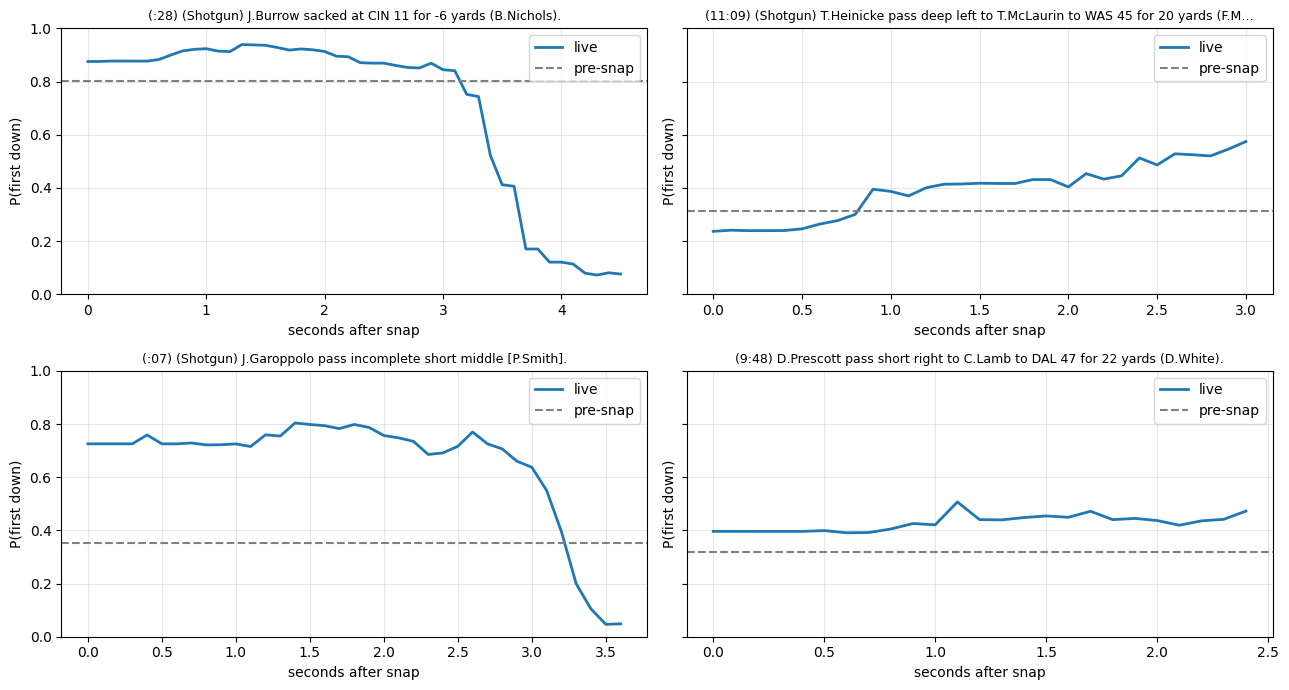

In [9]:
desc = plays.set_index(M.PLAY_KEY).playDescription

def pick(frame, n=1):
    return [tuple(k) for k in frame[M.PLAY_KEY].head(n).to_numpy()]

examples = (
    pick(summ[summ.passResult == "S"].sort_values("delta")) +                      # sack: big drop
    pick(summ[summ.converted == 1].sort_values("delta", ascending=False)) +        # conversion: big rise
    pick(summ[(summ.passResult == "I") & (summ.time_to_end > 3)].sort_values("delta")) +  # long pocket, incomplete
    pick(summ[(summ.passResult == "C") & (summ.converted == 1) & summ.p_snap.between(.3, .4)])  # ordinary conversion
)
fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharey=True)
for ax, key in zip(axes.flat, examples):
    g = oof[(oof.gameId == key[0]) & (oof.playId == key[1])]
    ax.plot(g.t, g.p_live, lw=2, label="live")
    ax.axhline(g.p_presnap.iloc[0], ls="--", c="gray", label="pre-snap")
    ax.set(ylim=(0, 1), xlabel="seconds after snap", ylabel="P(first down)")
    text = desc.loc[key]
    ax.set_title((text[:85] + "…") if len(text) > 85 else text, fontsize=9)
    ax.legend(loc="upper right"); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 6. ΔP leaderboards

ΔP = live probability at the end of the pocket phase − live probability at the snap, averaged over plays.

* **Offense / QB:** positive means the post-snap play (protection + QB + receivers) tends to improve the odds.
* **Defense:** negative is good; the rush and coverage make things worse for the offense.

These are 8 weeks of data, so differences of a few hundredths between teams are mostly noise.

In [10]:
pff = pd.read_csv(F.DATA_DIR / "pffScoutingData.csv", usecols=["gameId", "playId", "nflId", "pff_role"])
names = pd.read_csv(F.DATA_DIR / "players.csv", usecols=["nflId", "displayName"])
qbs = (pff[pff.pff_role == "Pass"].drop_duplicates(M.PLAY_KEY).merge(names, on="nflId")
       [M.PLAY_KEY + ["displayName"]].rename(columns={"displayName": "qb"}))
summ = summ.drop(columns=["qb"], errors="ignore").merge(qbs, on=M.PLAY_KEY, how="left")

def board(col, min_plays, ascending=False):
    g = summ.groupby(col).agg(plays=("delta", "size"), avg_delta=("delta", "mean"),
                              avg_p_snap=("p_snap", "mean"), conv_rate=("converted", "mean"))
    return g[g.plays >= min_plays].sort_values("avg_delta", ascending=ascending).round(3)

print("Offenses (higher = better)"); display(board("possessionTeam", 100).head(10))
print("Defenses (lower = better)"); display(board("defensiveTeam", 100, ascending=True).head(10))
print("Quarterbacks, ≥150 dropbacks (higher = better)"); display(board("qb", 150).head(15))

Offenses (higher = better)


,plays,avg_delta,avg_p_snap,conv_rate
possessionTeam,,,,
TB,299,0.014,0.355,0.401
LA,239,-0.003,0.365,0.431
ARI,220,-0.007,0.334,0.368
WAS,279,-0.008,0.343,0.330
BUF,238,-0.009,0.349,0.395
SF,201,-0.014,0.349,0.378
DAL,235,-0.014,0.357,0.417
ATL,268,-0.018,0.361,0.340
JAX,244,-0.019,0.362,0.303


Defenses (lower = better)


,plays,avg_delta,avg_p_snap,conv_rate
defensiveTeam,,,,
CAR,239,-0.057,0.367,0.343
CLE,238,-0.048,0.362,0.332
ARI,250,-0.038,0.358,0.308
BUF,223,-0.038,0.366,0.287
BAL,243,-0.034,0.355,0.362
NE,264,-0.033,0.354,0.318
CIN,311,-0.033,0.348,0.328
NYJ,233,-0.032,0.369,0.348
TEN,288,-0.032,0.355,0.302


Quarterbacks, ≥150 dropbacks (higher = better)


,plays,avg_delta,avg_p_snap,conv_rate
qb,,,,
Tom Brady,296,0.013,0.355,0.402
Matthew Stafford,235,0.000,0.363,0.438
Taylor Heinicke,272,-0.005,0.343,0.338
Kyler Murray,220,-0.007,0.334,0.368
Josh Allen,235,-0.010,0.349,0.396
Dak Prescott,194,-0.012,0.360,0.433
Matt Ryan,266,-0.018,0.361,0.342
Trevor Lawrence,244,-0.019,0.362,0.303
Mac Jones,264,-0.020,0.354,0.314


## 7. Export for the viewer / presentation

* `outputs/live_probabilities.csv`: one row per frame (`gameId, playId, frameId, t, p_live, p_presnap`)
* `outputs/play_summary.csv`: one row per play (snap / end probability, ΔP, outcome, QB)

In [11]:
oof[M.PLAY_KEY + ["frameId", "t", "p_live", "p_presnap"]].round(4).to_csv(OUT / "live_probabilities.csv", index=False)
summ.round(4).to_csv(OUT / "play_summary.csv", index=False)
for f in ["live_probabilities.csv", "play_summary.csv"]:
    print(f, f"{(OUT / f).stat().st_size / 1e6:.1f} MB")

live_probabilities.csv 9.3 MB
play_summary.csv 0.7 MB
